# **TFG: Sistema de detección de phishing de sitios web mediante técnicas de machine learning y análisis dinámico de URLs**

## **EDA - Phishing Website Dataset (Zenodo)**


### **Objetivo:** cargar los ficheros phishing.csv y not-phishing.csv, unirlos en un único dataset etiquetado y realizar un análisis exploratorio básico (tamaño, columnas, nulos, duplicados y balanceo de clases).


In [ ]:
# Cargamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
# Cargamos los csv que tenemos
df_phishing = pd.read_csv("phishing.csv")
df_not_phishing = pd.read_csv("not-phishing.csv")

In [ ]:
# Observamos las filas y columnas que tiene cada csv
df_phishing.shape, df_not_phishing.shape

((5151, 30), (5244, 29))

In [ ]:
# Creamos la variables objetivo (label)
df_phishing["label"] = 1
df_not_phishing["label"] = 0

In [ ]:
# Alineamos las columnas comunes para unir ambos datasets

common_columns = list(set(df_phishing.columns) & set(df_not_phishing.columns))

df_phishing_common = df_phishing[common_columns]
df_not_phishing_common = df_not_phishing[common_columns]

df = pd.concat([df_phishing_common, df_not_phishing_common], ignore_index=True)

In [ ]:
# Datasets unidos
df.shape

(10395, 30)

In [ ]:
# Mostramos los nombres de las columnas del dataset
df.columns


Index(['domain', 'remote_ip_isp', 'scan_date', 'protocol', 'security_valid_to',
       'whois_registry_created_at', 'remote_ip_address', 'features.text',
       'whois_registry_expired_at', '_id', 'whois_domain_age', 'features.css',
       'security_issuer', 'whois_registrar', 'security_valid_from',
       'folder_path', 'remote_ip_domain', 'remote_ip_country',
       'security_protocol', 'assets_downloaded', 'label', 'remote_ip_asn',
       'security_state', 'whois_raw_text', 'features.html',
       'whois_registry_updated_at', 'url', 'remote_ip_isp_org',
       'whois_registrar_url', 'language'],
      dtype='object')

In [ ]:
# Mostramos las primeras filas del dataset
df.head()


,domain,remote_ip_isp,scan_date,protocol,security_valid_to,whois_registry_created_at,remote_ip_address,features.text,whois_registry_expired_at,_id,...,label,remote_ip_asn,security_state,whois_raw_text,features.html,whois_registry_updated_at,url,remote_ip_isp_org,whois_registrar_url,language
0,compactdrivesolu.blob.core.windows.net,Microsoft Corporation,2023-03-03T05:53:36.270Z,http/1.1,2023-12-23T11:53:59.000Z,1995-08-10T04:00:00.000Z,20.60.134.228,\n Sharing Link Validation\n \n Verify Your Id...,2023-06-04T16:06:16.000Z,64038b0e2e9df665fc7353ff,...,1,8075.0,secure,Domain Name: WINDOWS.NET\r\n Registry Dom...,"[""html"", ""head"", ""meta"", ""title"", ""style"", ""li...",2022-05-09T19:17:07.000Z,https://compactdrivesolu.blob.core.windows.net...,Microsoft Corporation,http://www.markmonitor.com,en
1,bafkreifefpvr26zfog4s27pxbtd3tqmtatd34e374cvv4...,Protocol Labs,2023-03-04T02:20:09.412Z,h2,2023-04-10T17:16:23.000Z,2017-02-24T01:05:26.675Z,209.94.90.1,\n Sign in to your account\n \n Sign in\n \n E...,2024-02-24T01:05:26.675Z,640393d7a8281bcf8be471a4,...,1,40680.0,secure,Domain Name: dweb.link\r\nRegistry Domain ID: ...,"[""html"", ""head"", ""script"", ""meta"", ""title"", ""m...",2023-01-23T21:09:56.296Z,https://bafkreifefpvr26zfog4s27pxbtd3tqmtatd34...,Protocol Labs,www.cscglobal.com,en
2,ups-trackid728912.is-certified.com,"DigitalOcean, LLC",2023-03-03T13:12:48.188Z,http/1.1,NaN,2007-01-04T14:10:49.000Z,46.101.228.158,\n Global Shipping & Logistics Services | UPS ...,2024-01-04T14:10:49.000Z,640394d3a8281bcf8be471a8,...,1,14061.0,insecure,Domain Name: IS-CERTIFIED.COM\r\n Registr...,"[""html"", ""head"", ""meta"", ""title"", ""meta"", ""met...",2022-12-06T06:48:20.000Z,http://ups-trackid728912.is-certified.com/Find...,"DigitalOcean, LLC",http://www.tucows.com,en
3,southcoastaletrail.net.au,Dreamscape Networks Limited,2023-03-03T13:22:23.400Z,h2,2023-10-30T23:59:59.000Z,NaN,27.54.81.161,\n Sharing Link Validation\n \n Onedrive\n \n ...,NaN,64039cc2a8281bcf8be471b5,...,1,38719.0,secure,WHOIS LIMIT EXCEEDED\n,"[""html"", ""head"", ""meta"", ""title"", ""link"", ""bod...",NaN,https://southcoastaletrail.net.au/original/tec...,Dreamscape Networks PTY LTD,NaN,en
4,sksadesign.com,SKSA TECHNOLOGY SDN BHD,2023-01-30T17:27:02.863Z,http/1.1,2023-04-16T04:36:29.000Z,2013-01-17T06:47:49.000Z,103.8.25.216,\n DHL\n \n 專業及可靠的付運服務\n \n 客户服务\n \n 全天候24小時客...,2024-01-17T06:47:49.000Z,6403a15fa8281bcf8be471c4,...,1,132241.0,secure,Domain Name: SKSADESIGN.COM\r\n Registry ...,"[""html"", ""head"", ""meta"", ""meta"", ""title"", ""lin...",2022-12-19T06:11:52.000Z,https://sksadesign.com/@/GlobalSources/,SKSA TECHNOLOGY SDN BHD,http://www.publicdomainregistry.com,ko


In [ ]:
# Información general del dataset (tipos de datos y valores no nulos)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10395 entries, 0 to 10394
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   domain                     10395 non-null  object 
 1   remote_ip_isp              10391 non-null  object 
 2   scan_date                  10395 non-null  object 
 3   protocol                   10395 non-null  object 
 4   security_valid_to          8265 non-null   object 
 5   whois_registry_created_at  8878 non-null   object 
 6   remote_ip_address          10395 non-null  object 
 7   features.text              10395 non-null  object 
 8   whois_registry_expired_at  8818 non-null   object 
 9   _id                        10395 non-null  object 
 10  whois_domain_age           8878 non-null   float64
 11  features.css               10395 non-null  object 
 12  security_issuer            8262 non-null   object 
 13  whois_registrar            0 non-null      flo

In [ ]:
# Contamos los valores nulos que hay por columna
df.isnull().sum().sort_values(ascending=False)


,0
whois_registrar,10395
whois_registrar_url,2528
security_issuer,2133
security_valid_to,2130
security_valid_from,2130
security_protocol,2130
whois_registry_updated_at,1649
whois_registry_expired_at,1577
whois_domain_age,1517
whois_registry_created_at,1517


In [ ]:
# Eliminamos las columnas que están completamente vacías
df = df.dropna(axis=1, how="all")


In [ ]:
# Comprobamos el número de columnas tras la limpieza inicial que hemos hecho
df.shape


(10395, 29)

In [ ]:
# Comprobamos el número de filas duplicadas que hay
df.duplicated().sum()


np.int64(0)

In [ ]:
# Contamos el número de ejemplos que hay por clase
df["label"].value_counts()


,count
label,
0,5244
1,5151


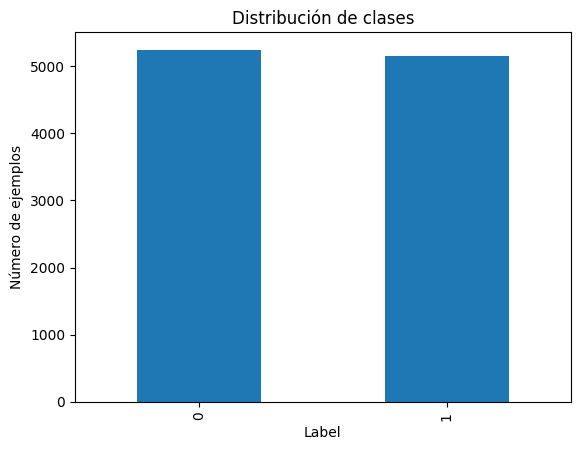

In [ ]:
# Visualizamos una distribución de clases
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Label")
plt.ylabel("Número de ejemplos")
plt.title("Distribución de clases")
plt.show()


### Limpieza y selección de columnas

In [ ]:
# Creamos una copia del dataset para trabajar con ella
df_clean = df.copy()


In [ ]:
# Eliminamos las columnas que no son relevantes para el modelado
columns_to_drop = [
    "_id",
    "folder_path",
    "features.html",
    "features.text",
    "features.css",
    "whois_raw_text",
    "scan_date"
]

df_clean = df_clean.drop(columns=columns_to_drop)


In [ ]:
# Comprobamos las dimensiones tras la eliminación de columnas
df_clean.shape


(10395, 22)

In [ ]:
# Mostramos las columnas finales tras la limpieza inicial
df_clean.columns


Index(['domain', 'remote_ip_isp', 'protocol', 'security_valid_to',
       'whois_registry_created_at', 'remote_ip_address',
       'whois_registry_expired_at', 'whois_domain_age', 'security_issuer',
       'security_valid_from', 'remote_ip_domain', 'remote_ip_country',
       'security_protocol', 'assets_downloaded', 'label', 'remote_ip_asn',
       'security_state', 'whois_registry_updated_at', 'url',
       'remote_ip_isp_org', 'whois_registrar_url', 'language'],
      dtype='object')

### Tratamiento de valores nulos

In [ ]:
# Identificamos las columnas numéricas y categóricas
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object"]).columns


In [ ]:
# Rellenamos los valores nulos en las columnas numéricas con la mediana
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())


In [ ]:
# Rellenamos los valores nulos en columnas categóricas con 'unknown'
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna("unknown")


In [ ]:
# Comprobamos que no quedan valores nulos
df_clean.isnull().sum().sum()


np.int64(0)

### Preparamos el dataset para Machine Learning (encoding)

In [ ]:
# Separamos variables (X) y etiqueta (y)
X = df_clean.drop(columns=["label"])
y = df_clean["label"]


In [ ]:
# Aplicamos one-hot encoding a las variables categóricas
X_encoded = pd.get_dummies(X, drop_first=True)


In [ ]:
# Comprobamos las dimensiones antes y después del encoding
X.shape, X_encoded.shape


((10395, 21), (10395, 59517))

Como vemos que la cantidad de columnas asciende mucho al hacer el one-hot encoding vamos a ir por otro camino

### Vemos cuántos valores únicos tienen algunas columnas (para decidir qué codificar)

In [ ]:
# Vemos la cardinalidad (número de valores únicos) de las columnas categóricas principales
cols_check = ["protocol", "security_state", "security_protocol", "security_issuer", "language", "remote_ip_country"]
df_clean[cols_check].nunique()


,0
protocol,4
security_state,3
security_protocol,4
security_issuer,155
language,42
remote_ip_country,93


Elegimos las 3 primeras (protocol, security_state y security_protocol) que son las que tienen menor número de cardinalidad

### Extracción de características léxicas de la URL

In [ ]:
# Longitud total de la URL
df_clean["url_length"] = df_clean["url"].apply(len)


In [ ]:
# Número de subdominios en la URL
df_clean["num_subdomains"] = df_clean["domain"].apply(lambda x: x.count("."))


In [ ]:
# Número de dígitos en la URL
df_clean["num_digits"] = df_clean["url"].apply(lambda x: sum(char.isdigit() for char in x))


In [ ]:
# Número de caracteres especiales en la URL (símbolos típicos usados en phishing)
special_chars = ["@", "-", "_", "?", "=", "&", "%"]
df_clean["num_special_chars"] = df_clean["url"].apply(
    lambda x: sum(x.count(char) for char in special_chars)
)


In [ ]:
# Detectamos si la URL contiene una dirección IP
df_clean["has_ip"] = df_clean["url"].apply(
    lambda x: 1 if any(char.isdigit() for char in x.split("//")[-1].split("/")[0]) and "." in x else 0
)


In [ ]:
# Mostramos algunas filas con las nuevas características
df_clean[["url_length", "num_subdomains", "num_digits", "num_special_chars", "has_ip"]].head()


,url_length,num_subdomains,num_digits,num_special_chars,has_ip
0,62,4,0,0,0
1,83,3,12,0,1
2,203,2,29,6,1
3,68,2,4,2,0
4,39,1,0,1,0


### Construimos el dataset final para Machine Learning

In [ ]:
# Seleccionamos las columnas numéricas que son útiles
numeric_features = [
    "assets_downloaded",
    "remote_ip_asn",
    "whois_domain_age",
    "url_length",
    "num_subdomains",
    "num_digits",
    "num_special_chars",
    "has_ip"
]


In [ ]:
# Seleccionamos las columnas categóricas de baja cardinalidad
categorical_features = [
    "protocol",
    "security_state",
    "security_protocol"
]


In [ ]:
# Creamos el dataset final para ML
X_final = df_clean[numeric_features + categorical_features]
y_final = df_clean["label"]


In [ ]:
# Aplicamos one-hot encoding solo a variables categóricas seleccionadas
X_final_encoded = pd.get_dummies(X_final, columns=categorical_features, drop_first=True)


In [ ]:
# Dimensiones finales del dataset para ML
X_final.shape, X_final_encoded.shape


((10395, 11), (10395, 16))

### División del dataset en entrenamiento y prueba

In [ ]:
# Dividimos el dataset en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X_final_encoded,
    y_final,
    test_size=0.2,
    random_state=30,
    stratify=y_final
)


In [ ]:
# Entrenamos el modelo baseline: Regresión Logística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Como hay features en escalas muy distintas hay variables que hacen que el optimizador necesite más iteraciones, entonces lo que ahremos será estandarizar (escalar) las variables antes de entrenar Logistic Regression.

In [ ]:
log_reg = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(max_iter=5000))
])

log_reg.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('model', LogisticRegression(max_iter=5000))])

In [ ]:
# Predicciones del modelo (clase y probabilidad)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]


In [ ]:
# Evaluamos el modelo con algunas métricas estándar
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Valor": [accuracy, precision, recall, f1, roc_auc]
})

metrics_df


,Métrica,Valor
0,Accuracy,0.795094
1,Precision,0.787619
2,Recall,0.802913
3,F1-score,0.795192
4,ROC-AUC,0.859789


### Random Forest (comparación)


In [ ]:
# Entrenamos el modelo baseline: Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=30,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=30)

In [ ]:
# Predicciones con Random Forest
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]


In [ ]:
# Métricas de evaluación del modelo Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

metrics_rf_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Valor": [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf]
})

metrics_rf_df


,Métrica,Valor
0,Accuracy,0.881193
1,Precision,0.868992
2,Recall,0.895146
3,F1-score,0.881875
4,ROC-AUC,0.955952


### Tabla final comparativa (Regresión Logísitica vs Random Forest)

In [ ]:
# Creamos la tabla comparativa de métricas (Logistic Regression vs Random Forest)
comparison_df = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-score": [f1, f1_rf],
    "ROC-AUC": [roc_auc, roc_auc_rf]
})

comparison_df.round(4)


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7951,0.7876,0.8029,0.7952,0.8598
1,Random Forest,0.8812,0.8690,0.8951,0.8819,0.9560


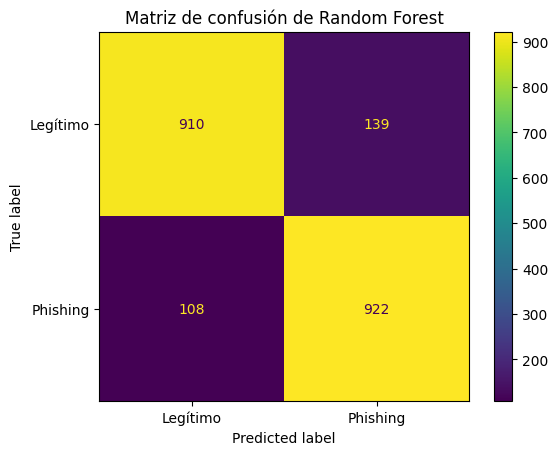

In [ ]:
# Matriz de confusión para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Legítimo", "Phishing"])
disp.plot()
plt.title("Matriz de confusión de Random Forest")
plt.show()

910 Verdaderos Negativos (TN)
--> URLs legítimas correctamente clasificadas como legítimas.

922 Verdaderos Positivos (TP)
--> URLs de phishing correctamente detectadas como phishing.

139 Falsos Positivos (FP)
--> URLs legítimas marcadas erróneamente como phishing
(molesto, pero menos crítico en ciberseguridad).

108 Falsos Negativos (FN)
--> URLs de phishing no detectadas
(esto es lo más peligroso, y aquí el número que nos ha dado es relativamente bajo)

In [ ]:
# Convertimos la columna scan_date a formato datetime (por si está como texto)
df['scan_date'] = pd.to_datetime(df['scan_date'], errors='coerce')

# Comprobamos el tipo de dato
df['scan_date'].dtype

datetime64[ns, UTC]

In [ ]:
# Obtenemos la fecha más antigua y más reciente del dataset
fecha_min = df['scan_date'].min()
fecha_max = df['scan_date'].max()

fecha_min, fecha_max

(Timestamp('2018-12-08 00:22:51.482000+0000', tz='UTC'),
 Timestamp('2023-05-08 08:06:20.214000+0000', tz='UTC'))

In [ ]:
# Extraemos año-mes
df['year_month'] = df['scan_date'].dt.to_period('M')

# Conteo por mes
df['year_month'].value_counts().sort_index()

/tmp/ipykernel_224/3144099568.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['scan_date'].dt.to_period('M')


,count
year_month,
2018-12,1
2019-05,1
2019-10,1
2020-12,1
2021-04,1
2021-05,1
2021-08,14
2021-09,49
2021-10,62
